In [1]:
from src.preprocessamento import carregar_dados, aplicar_log, std_scaler, executar_undersampling, executar_smote, preparar_dados_treino_teste
from src.modelos import treinar_regressao_logistica, treinar_random_forest, treinar_xgboost, otimizar_xgboost_grid, avaliar_modelo, plotar_curvas, plotar_shap, plotar_importancia_variaveis

In [2]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = carregar_dados(url)

print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [3]:
print(df["Class"].value_counts(normalize=True))

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [4]:
df = aplicar_log(df, coluna="Amount")

print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [5]:
X_train, X_test, y_train, y_test = preparar_dados_treino_teste(df)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (227845, 30)
X_test shape:  (56962, 30)
y_train shape: (227845,)
y_test shape:  (56962,)


In [6]:
X_train, scaler_time = std_scaler(X_train, "Time")

X_test, _ = std_scaler(X_test, "Time", scaler=scaler_time)

print(f"Dimensões do X_train pós-escala: {X_train.shape}")
print(f"Dimensões do X_test pós-escala: {X_test.shape}\n")

print("--- Estatísticas da coluna 'Time_scaler' no Treino ---")
print(X_train["Time_scaler"].describe())

print("\n--- Estatísticas da coluna 'Time_scaler' no Teste ---")
print(X_test["Time_scaler"].describe())

X_train.head(3)

Dimensões do X_train pós-escala: (227845, 30)
Dimensões do X_test pós-escala: (56962, 30)

--- Estatísticas da coluna 'Time_scaler' no Treino ---
count    2.278450e+05
mean    -1.407707e-16
std      1.000002e+00
min     -1.998073e+00
25%     -8.561495e-01
50%     -2.122647e-01
75%      9.366285e-01
max      1.640549e+00
Name: Time_scaler, dtype: float64

--- Estatísticas da coluna 'Time_scaler' no Teste ---
count    56962.000000
mean        -0.007500
std          0.999960
min         -1.998031
25%         -0.858977
50%         -0.219182
75%          0.931985
max          1.640423
Name: Time_scaler, dtype: float64


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount_log,Time_scaler
265518,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,-0.157403,...,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,2.118662,1.411588
180305,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,0.284864,...,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,1.383791,0.623141
42664,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,-2.009561,...,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,5.171052,-1.130680


In [7]:
df_treino_temp = X_train.copy()
df_treino_temp["Class"] = y_train

df_treino_under = executar_undersampling(df_treino_temp, alvo="Class")
X_train_under = df_treino_under.drop(columns=["Class"])
y_train_under = df_treino_under["Class"]

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962

ROC AUC Score: 0.9763


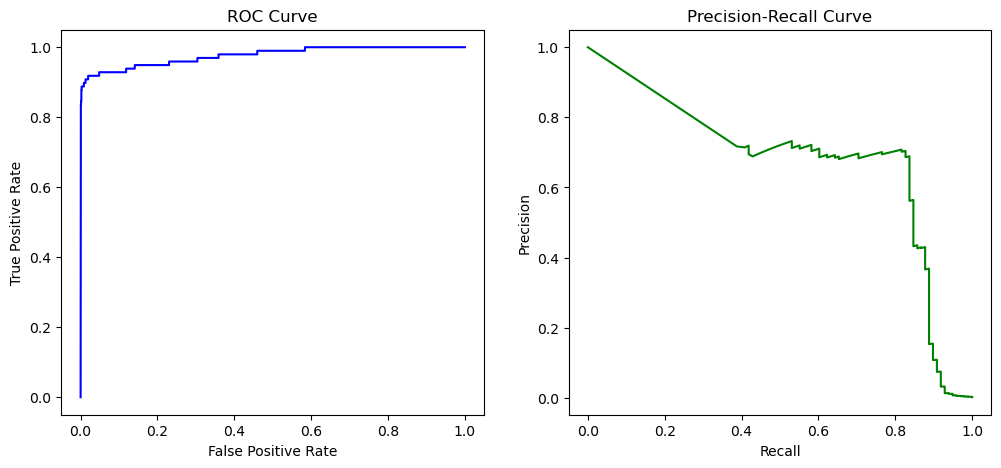

In [8]:
modelo_lr_under = treinar_regressao_logistica(X_train_under, y_train_under)
avaliar_modelo(modelo_lr_under, X_test, y_test)
plotar_curvas(modelo_lr_under, X_test, y_test)

In [9]:
X_train_smote, y_train_smote = executar_smote(X_train, y_train)

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC AUC Score: 0.9695


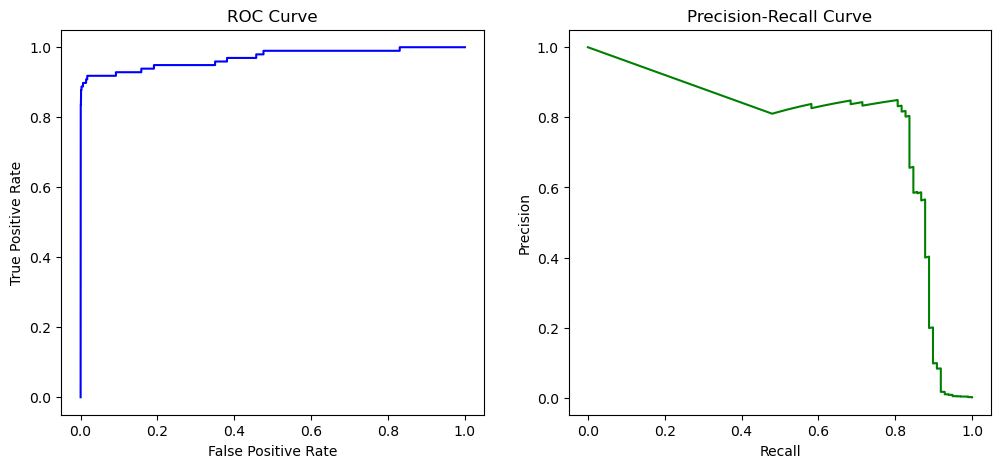

In [10]:
modelo_lr_smote = treinar_regressao_logistica(X_train_smote, y_train_smote)
avaliar_modelo(modelo_lr_smote, X_test, y_test)
plotar_curvas(modelo_lr_smote, X_test, y_test)

In [11]:
modelo_rf = treinar_random_forest(X_train, y_train)
avaliar_modelo(modelo_rf, X_test, y_test)

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.9802


In [12]:
modelo_xgb = treinar_xgboost(X_train, y_train, scale_pos_weight=10)
avaliar_modelo(modelo_xgb, X_test, y_test)

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.81      0.85        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.9724


In [13]:
avaliar_modelo(modelo_xgb, X_test, y_test, custom_threshold=0.3)

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.9724


In [14]:
melhor_xgb, melhores_parametros = otimizar_xgboost_grid(X_train, y_train)
print("Melhores parâmetros encontrados:", melhores_parametros)
avaliar_modelo(melhor_xgb, X_test, y_test)

Melhores parâmetros encontrados: {'max_depth': 5, 'n_estimators': 100}
--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.77      0.81        98

    accuracy                           1.00     56962
   macro avg       0.93      0.88      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.9360


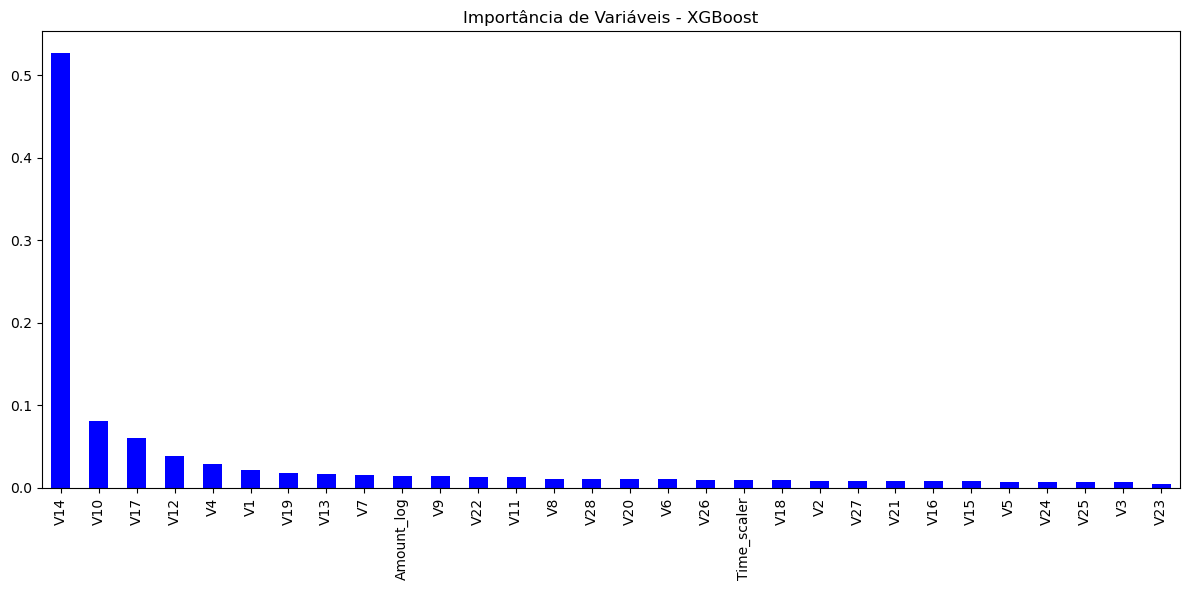

In [16]:
plotar_importancia_variaveis(modelo_xgb, X_train)

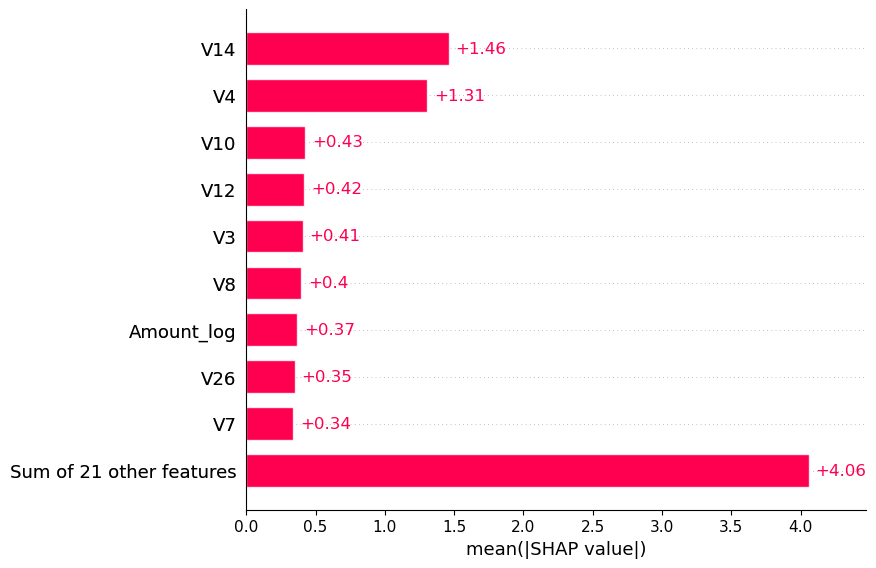

In [15]:
plotar_shap(modelo_xgb, X_test)